# Football Match Score Prediction with Probabilistic Modeling

In this notebook, we aim to predict football match scores for home and away teams using probabilistic models that output integer scores. 

The predictions are based on features extracted from historical match data, and the model architecture ensures outputs align with the discrete nature of football scores. This approach avoids approximations like rounding by directly predicting probabilities over possible scores and selecting the most likely score.

The pipeline includes the following stages:
- **Data Preprocessing**: Cleaning and transforming historical match data for modeling.
- **Feature Engineering**: Identifying and optimizing key predictors.
- **Modeling**: Training and evaluating multiple regression models with and without hyperparameter tuning.
- **Performance Evaluation**: Comparing model outputs using metrics and visualizations.


### Step 1: Import Libraries and Load Dataset
This section initializes the notebook by importing essential libraries for data processing, visualization, and modeling. It also loads the dataset containing historical football match data for analysis.

In [77]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_squared_error
import seaborn as sns


# Load the dataset containing match statistics
df = pd.read_csv("../data/england-premier-league-matches-2018-to-2019-stats.csv")


### Step 2: Explore the Dataset
This section examines the structure of the dataset and identifies specific columns, such as those related to betting odds, pre-match statistics, and null values, for potential preprocessing.


In [78]:
# Display the first few rows of the dataset to understand its structure
df.head()

# Identify columns related to betting odds
odds_columns = [col for col in df.columns if 'odds' in col.lower()]
df[odds_columns].sample()

# Identify columns related to pre-match statistics
prematch_columns = [col for col in df.columns if 'pre' in col.lower() and 'match' in col.lower()]
df[prematch_columns].sample()

# Identify columns with all null values
null_columns = [col for col in df.columns if (df[col] == 0).all()]
df[null_columns].head()

# Check for incomplete matches based on the 'status' column
not_completed = [col for col in df.columns if (df['status'] != 'complete').any()]
print("Incomplete Matches Columns:", not_completed)

# Identify percentage-related columns
percentage_columns = [col for col in df.columns if 'percentage' in col.lower()]
print("Percentage Columns:", percentage_columns)


Incomplete Matches Columns: []
Percentage Columns: ['btts_percentage_pre_match', 'over_15_percentage_pre_match', 'over_25_percentage_pre_match', 'over_35_percentage_pre_match', 'over_45_percentage_pre_match', 'over_15_HT_FHG_percentage_pre_match', 'over_05_HT_FHG_percentage_pre_match', 'over_15_2HG_percentage_pre_match', 'over_05_2HG_percentage_pre_match']


#### **Datacleaning: Description**:
- Remove irrelevant and odds-related columns.
- Process `date_GMT` into meaningful date-related features.
- Encode categorical columns (e.g., team names, referee names).
- Drop unnecessary features like pre-match statistics for early games.
- Fill missing values for numeric columns with the column mean.


### Step 3: Data Cleaning and Feature Engineering
This section performs essential preprocessing steps to prepare the dataset for machine learning models:
- Encodes categorical variables using label encoding for compatibility with numerical models.
- Extracts useful date-related features (month, day, and weekday) from the match dates.
- Removes columns deemed irrelevant or redundant, ensuring only meaningful features remain.

In [79]:
# Remove columns related to odds and percentages, as they are not relevant for prediction
df_filtered = df.drop(columns=odds_columns + percentage_columns)

# Handle missing data for pre-match statistics in early matches
df_filtered.loc[df_filtered['Game Week'] <= 2, prematch_columns] = np.nan

# Parse 'date_GMT' to extract meaningful date-based features
df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')
df_filtered['match_month'] = df_filtered['match_date'].dt.month
df_filtered['match_day'] = df_filtered['match_date'].dt.day
df_filtered['match_weekday'] = df_filtered['match_date'].dt.weekday
df_filtered = df_filtered.drop(columns=['date_GMT', 'match_date'])

# Encode categorical columns (e.g., team names, stadiums, referees)
categorical_columns = ['home_team_name', 'away_team_name', 'stadium_name', 'referee']
label_encoders = {}
for col in categorical_columns:
    df_filtered[col] = df_filtered[col].fillna("Unknown")  # Replace missing values with "Unknown"
    le = LabelEncoder()  # Initialize label encoder
    df_filtered[col] = le.fit_transform(df_filtered[col].astype(str))  # Encode the column
    label_encoders[col] = le  # Store the encoder for future use

# Remove redundant or irrelevant columns
df_filtered = df_filtered.drop(columns=[
    'status', 'home_team_goal_timings', 'away_team_goal_timings',
    'btts_percentage_pre_match', 'over_15_percentage_pre_match',
    'over_25_percentage_pre_match', 'over_35_percentage_pre_match',
    'over_45_percentage_pre_match', 'over_15_HT_FHG_percentage_pre_match',
    'over_05_HT_FHG_percentage_pre_match', 'over_15_2HG_percentage_pre_match',
    'over_05_2HG_percentage_pre_match', 'total_goal_count',
    'home_team_goal_count_half_time', 'away_team_goal_count_half_time',
    'total_goals_at_half_time'
])

# Fill missing values for numeric columns with their column mean
numeric_columns = df_filtered.select_dtypes(include=[np.number]).columns
df_filtered[numeric_columns] = df_filtered[numeric_columns].fillna(df_filtered[numeric_columns].mean())

# Display the first few rows of the dataset to see its new structure
df.head()

C:\Users\sande\AppData\Local\Temp\ipykernel_33868\524043366.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')


,timestamp,date_GMT,status,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),...,odds_ft_home_team_win,odds_ft_draw,odds_ft_away_team_win,odds_ft_over15,odds_ft_over25,odds_ft_over35,odds_ft_over45,odds_btts_yes,odds_btts_no,stadium_name
0,1533927600,Aug 10 2018 - 7:00pm,complete,74439,Manchester United,Leicester City,Andre Marriner,1,0.0,0.0,...,1.37,4.98,9.81,1.33,2.00,3.60,7.50,2.05,1.69,Old Trafford (Manchester)
1,1533987000,Aug 11 2018 - 11:30am,complete,51749,Newcastle United,Tottenham Hotspur,Martin Atkinson,1,0.0,0.0,...,4.51,3.77,1.84,1.31,1.95,3.50,5.75,1.83,1.87,St. James' Park (Newcastle upon Tyne)
2,1533996000,Aug 11 2018 - 2:00pm,complete,10353,AFC Bournemouth,Cardiff City,Kevin Friend,1,0.0,0.0,...,2.03,3.51,3.96,1.31,1.95,3.45,6.70,1.83,1.83,Vitality Stadium (Bournemouth- Dorset)
3,1533996000,Aug 11 2018 - 2:00pm,complete,24821,Fulham,Crystal Palace,Mike Dean,1,0.0,0.0,...,2.31,3.44,3.26,1.28,1.87,3.20,7.00,1.71,2.00,Craven Cottage (London)
4,1533996000,Aug 11 2018 - 2:00pm,complete,24121,Huddersfield Town,Chelsea,Chris Kavanagh,1,0.0,0.0,...,7.47,4.27,1.51,1.29,1.91,3.30,6.95,2.00,1.71,John Smith's Stadium (Huddersfield- West Yorks...


### Step 4: Correlation Analysis
This section calculates and visualizes:
1. The complete correlation matrix for all numeric features to explore overall feature relationships.
2. The specific correlations between all features and the target variables (`home_team_goal_count` and `away_team_goal_count`) to identify the most impactful features for prediction.


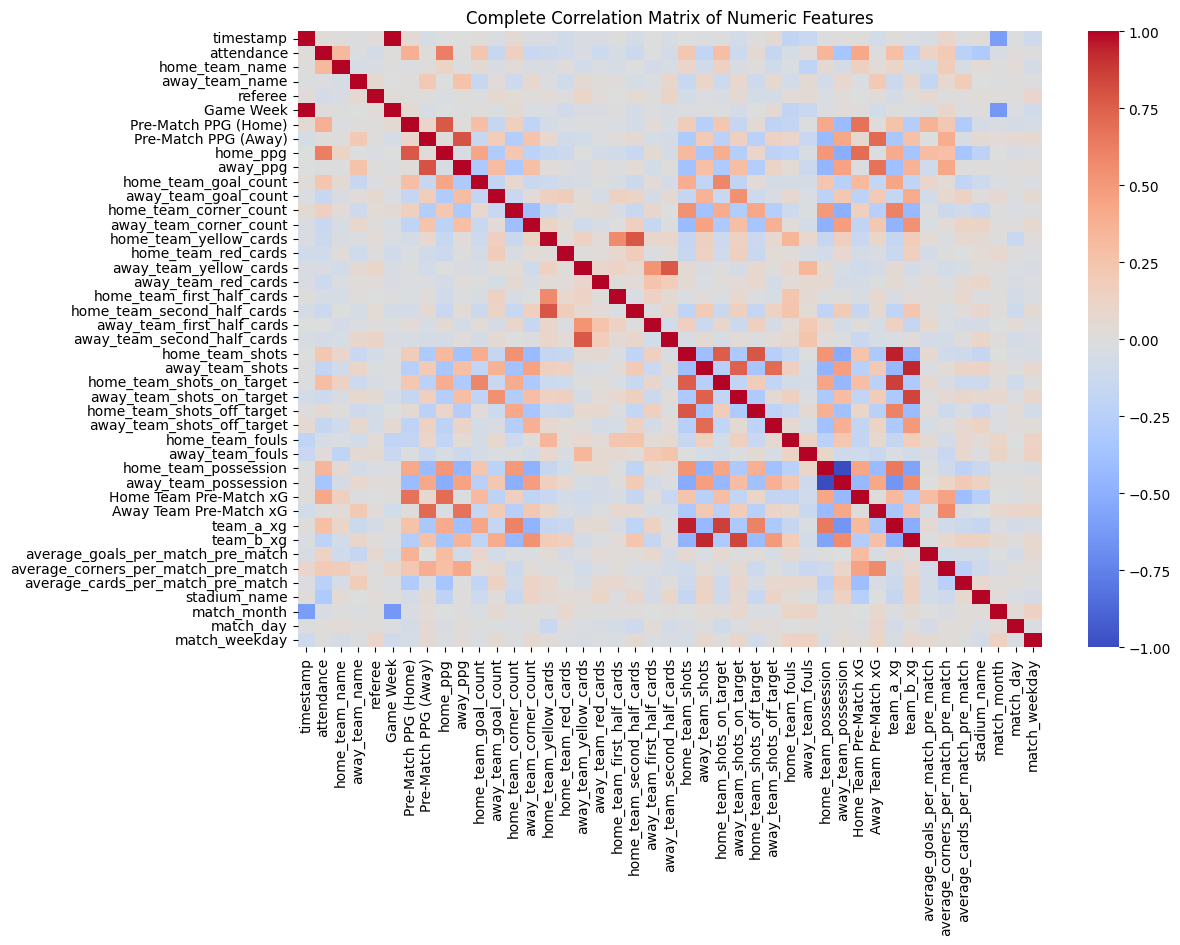

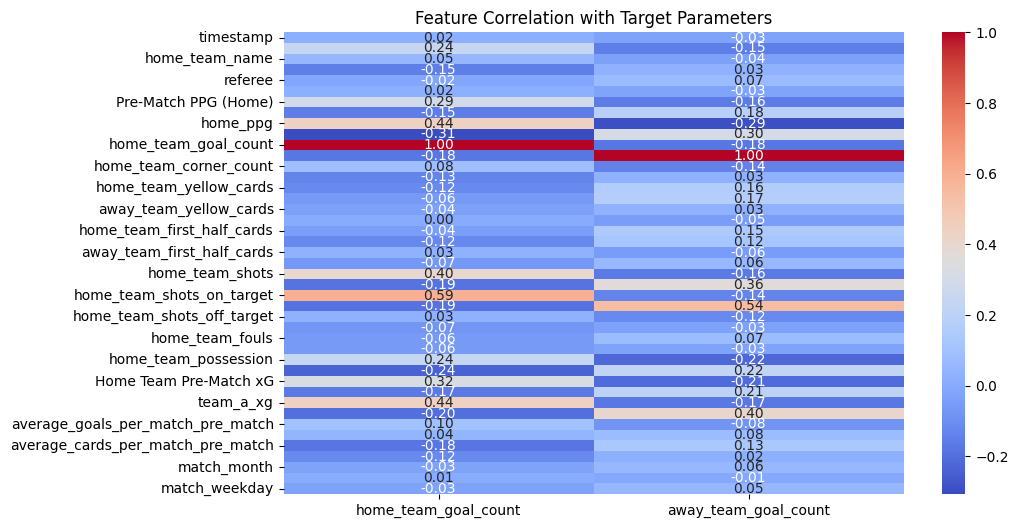

In [80]:
# Calculate the full correlation matrix for all numeric features
correlation_matrix = df_filtered.corr()

# Plot the complete correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Complete Correlation Matrix of Numeric Features")
plt.show()

# Calculate correlations between features and target variables
target_columns = ['home_team_goal_count', 'away_team_goal_count']
correlation_with_targets = df_filtered.corr()[target_columns]

# Print correlations with target variables
# print("Correlation with Target Variables:")
# print(correlation_with_targets)

# Plot correlations of features with target variables
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_with_targets, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation with Target Parameters")
plt.show()


### Step 5: Feature Importance and Recursive Feature Elimination (RFE)

In this section:
1.  `Random Forest Regressor` is used to compute the feature importance for predicting home and away team scores.
2. `Recursive Feature Elimination (RFE)` is applied to select the top 15 most important features for each target variable.


In [81]:
# Define feature columns
X = df_filtered.drop(columns=target_columns)
y_home = df_filtered['home_team_goal_count']
y_away = df_filtered['away_team_goal_count']

# Split dataset into train-test sets for home and away scores
X_train_home, X_test_home, y_train_home, y_test_home = train_test_split(X, y_home, test_size=0.2, random_state=42)
X_train_away, X_test_away, y_train_away, y_test_away = train_test_split(X, y_away, test_size=0.2, random_state=42)

# # First split: Training and remaining data
# X_train_home, X_temp_home, y_train_home, y_temp_home = train_test_split(X, y_home, test_size=0.3, random_state=42)
# X_train_away, X_temp_away, y_train_away, y_temp_away = train_test_split(X, y_away, test_size=0.3, random_state=42)

# # Second split: Validation and test data
# X_val_home, X_test_home, y_val_home, y_test_home = train_test_split(X_temp_home, y_temp_home, test_size=0.5, random_state=42)
# X_val_away, X_test_away, y_val_away, y_test_away = train_test_split(X_temp_away, y_temp_away, test_size=0.5, random_state=42)


# Train Random Forest models for home and away scores
rf_home = RandomForestRegressor(oob_score=True, random_state=42)
rf_home.fit(X_train_home, y_train_home)


rf_away = RandomForestRegressor(random_state=42)
rf_away.fit(X_train_away, y_train_away)

# Extract feature importance for home and away scores
importances_home = rf_home.feature_importances_
importances_away = rf_away.feature_importances_

# Create dataframes for feature importance
feature_importance_home_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_home})
feature_importance_away_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_away})

# Sort by importance
feature_importance_home_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_importance_away_df.sort_values(by='Importance', ascending=False, inplace=True)

# Evaluate models on test data
y_pred_home = rf_home.predict(X_test_home).round().astype(int)
y_pred_away = rf_away.predict(X_test_away).round().astype(int)

# Metrics for Home Scores
print("\n--- Home Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home)}")

# Metrics for Away Scores
print("\n--- Away Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away)}")


--- Home Team Scores ---
Mean Absolute Error (MAE): 0.881578947368421
Mean Squared Error (MSE): 1.381578947368421
R^2 Score: 0.11412078152753102

--- Away Team Scores ---
Mean Absolute Error (MAE): 0.6052631578947368
Mean Squared Error (MSE): 0.8947368421052632
R^2 Score: 0.1352074966532797


#### Visualizing Feature Importance

This section visualizes the top 15 most important features for predicting:
1. **Home Team Scores**
2. **Away Team Scores**

These visualizations provide insights into which features significantly influence the predictions for each target variable.


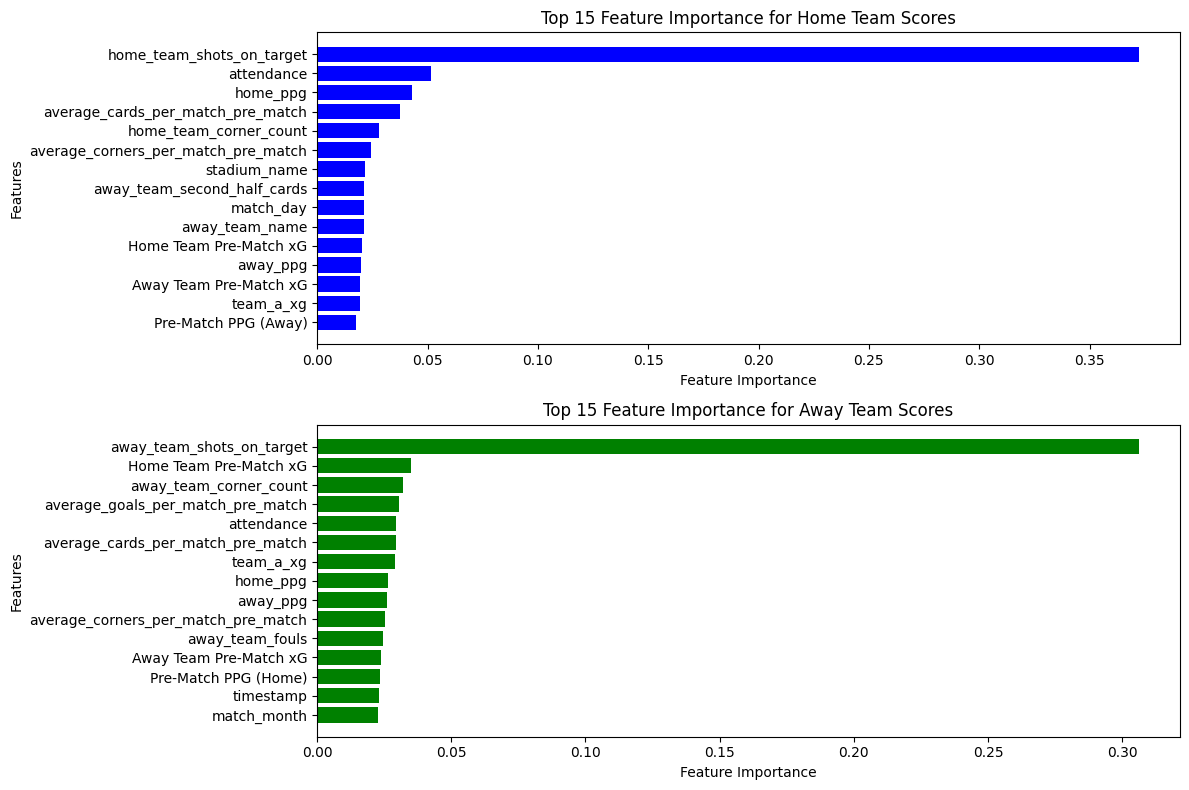

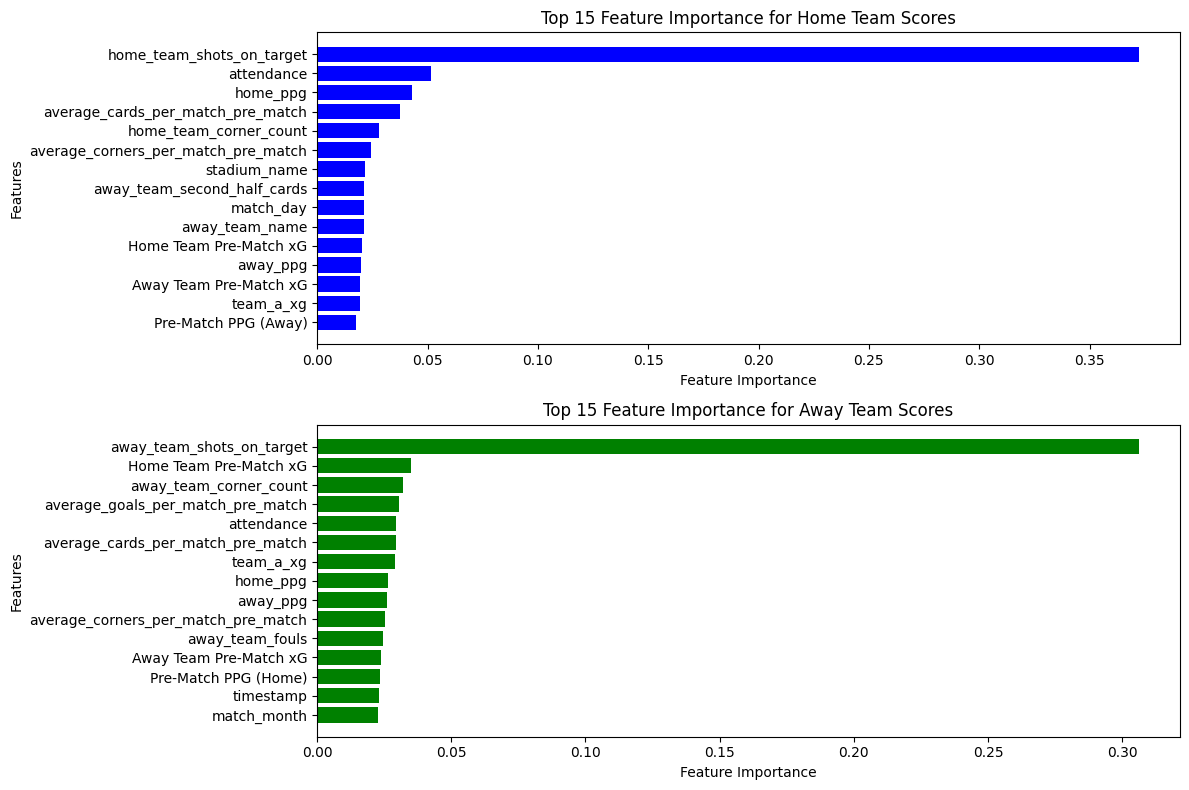

In [82]:
# Visualize Top Features
top_n = 15  # Number of features to display
top_features_home = feature_importance_home_df.head(top_n)
top_features_away = feature_importance_away_df.head(top_n)

# Top features home team
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.barh(top_features_home['Feature'], top_features_home['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Home Team Scores')
plt.gca().invert_yaxis()

# Top features away team
plt.subplot(2, 1, 2)
plt.barh(top_features_away['Feature'], top_features_away['Importance'], color='green')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Away Team Scores')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Top features home team
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.barh(top_features_home['Feature'], top_features_home['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Home Team Scores')
plt.gca().invert_yaxis()

# Top features away team
plt.subplot(2, 1, 2)
plt.barh(top_features_away['Feature'], top_features_away['Importance'], color='green')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Away Team Scores')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### `Recursive Feature Elimination (RFE)`:
- Using Recursive Feature Elimination (RFE), we reduce the feature set to the 15 most important features for each target variable.
- Train new `RandomForestRegressor` models on these reduced features and evaluate them.
- RFE helps eliminate less informative features iteratively, leading to simpler and potentially better-performing models.

In [83]:
# Applying RFE for Home Team Scores
rfe_home = RFE(estimator=rf_home, n_features_to_select=top_n) # top_n = 15
rfe_home.fit(X_train_home, y_train_home)
selected_features_home = X.columns[rfe_home.support_]

# Applying RFE for Away Team Scores
rfe_away = RFE(estimator=rf_away, n_features_to_select=top_n)
rfe_away.fit(X_train_away, y_train_away)
selected_features_away = X.columns[rfe_away.support_]

# Print selected features
print("Selected Features for Home Team Scores using RFE:", selected_features_home)
print("Selected Features for Away Team Scores using RFE:", selected_features_away)

# Train New RF Models on RFE-Selected Features
rf_home_rfe = RandomForestRegressor(oob_score=True, random_state=42)
rf_away_rfe = RandomForestRegressor(oob_score=True, random_state=42)

rf_home_rfe.fit(X_train_home[selected_features_home], y_train_home)
rf_away_rfe.fit(X_train_away[selected_features_away], y_train_away)

# Predictions with RFE-Selected Features
y_pred_home_rfe = rf_home_rfe.predict(X_test_home[selected_features_home]).round().astype(int)
y_pred_away_rfe = rf_away_rfe.predict(X_test_away[selected_features_away]).round().astype(int)

# Evaluate RFE Models
print("\n--- Home Team Scores (RFE Model) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_rfe)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_rfe)}")

print("\n--- Away Team Scores (RFE Model) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_rfe)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_rfe)}")

Selected Features for Home Team Scores using RFE: Index(['timestamp', 'attendance', 'away_team_name', 'home_ppg', 'away_ppg',
       'home_team_corner_count', 'away_team_second_half_cards',
       'home_team_shots_on_target', 'Home Team Pre-Match xG',
       'Away Team Pre-Match xG', 'team_a_xg', 'team_b_xg',
       'average_corners_per_match_pre_match',
       'average_cards_per_match_pre_match', 'match_day'],
      dtype='object')
Selected Features for Away Team Scores using RFE: Index(['timestamp', 'attendance', 'home_ppg', 'away_ppg',
       'away_team_corner_count', 'away_team_shots_on_target',
       'away_team_fouls', 'away_team_possession', 'Home Team Pre-Match xG',
       'Away Team Pre-Match xG', 'team_a_xg',
       'average_goals_per_match_pre_match',
       'average_corners_per_match_pre_match',
       'average_cards_per_match_pre_match', 'match_day'],
      dtype='object')

--- Home Team Scores (RFE Model) ---
Mean Absolute Error (MAE): 0.8552631578947368
Mean Squared Erro

#### Visualizing Difference of the Models

This section visualizes the evaluation results for the Home and Away teams for the models:
1. `Random Forest Regressor`
2. `Random Forest Regressor` utilizing `RFE`-selected features

These visualizations provide insights into how downscaling the number of features used influences the predictions for each model.


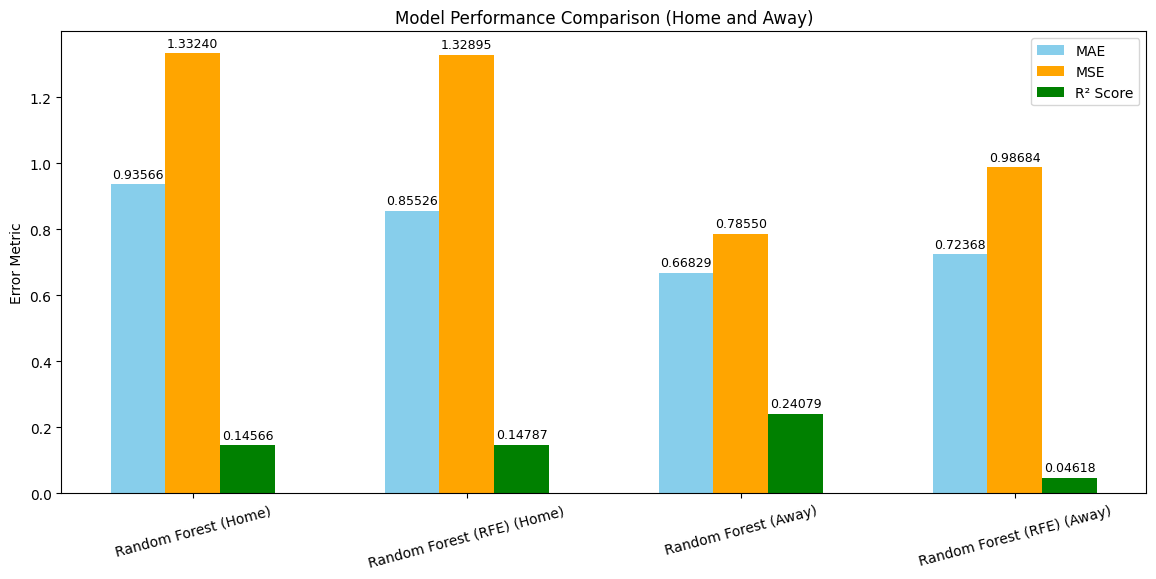

In [84]:
# Make a models list to include both model configurations for home and away
models = ['Random Forest (Home)', 'Random Forest (RFE) (Home)', 
          'Random Forest (Away)', 'Random Forest (RFE) (Away)']
x = np.arange(len(models))  # Update x-axis positions

# Evaluation Metrics
mae = [
    mean_absolute_error(y_test_home, rf_home.predict(X_test_home)),  # Home MAE
    mean_absolute_error(y_test_home, y_pred_home_rfe),              # Home RFE MAE
    mean_absolute_error(y_test_away, rf_away.predict(X_test_away)),  # Away MAE
    mean_absolute_error(y_test_away, y_pred_away_rfe)               # Away RFE MAE
]
mse = [
    mean_squared_error(y_test_home, rf_home.predict(X_test_home)),
    mean_squared_error(y_test_home, y_pred_home_rfe),
    mean_squared_error(y_test_away, rf_away.predict(X_test_away)),
    mean_squared_error(y_test_away, y_pred_away_rfe)
]
r2 = [
    r2_score(y_test_home, rf_home.predict(X_test_home)),
    r2_score(y_test_home, y_pred_home_rfe),
    r2_score(y_test_away, rf_away.predict(X_test_away)),
    r2_score(y_test_away, y_pred_away_rfe)
]

# Plot updated metrics
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
plt.bar(x, mse, 0.2, label='MSE', color='orange')
plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

# Add annotations
for i, (mae_val, mse_val, r2_val) in enumerate(zip(mae, mse, r2)):
    plt.text(x[i] - 0.2, mae_val + 0.02, f'{mae_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i], mse_val + 0.02, f'{mse_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i] + 0.2, r2_val + 0.02, f'{r2_val:.5f}', ha='center', fontsize=9)

plt.xticks(x, models, rotation=15)  # Rotate labels for better readability
plt.ylabel('Error Metric')
plt.title('Model Performance Comparison (Home and Away)')
plt.legend()
plt.show()


### Step 6. Gradient Boosting with ``XGBoost``

``XGBoost`` (``eXtreme Gradient Boosting``) is a powerful gradient boosting algorithm that often outperforms Random Forest on structured/tabular data due to its sequential error correction and advanced optimization techniques. Key advantages include:

- **Boosting**: Combines multiple weak learners (decision trees) into a strong model.
- **Gradient Optimization**: Minimizes loss functions like Mean Squared Error using gradient descent.
- **Regularization**: Prevents overfitting with parameters like gamma and lambda.
- **Efficiency**: Supports parallel processing and optimized memory usage for speed and scalability.
- **Flexibility**: Handles regression, classification, and ranking tasks while automatically managing missing values.

This section uses ``XGBoost`` models trained on all features, as we saw that restricting the model to ``RFE``-selected features yieded a poorer performance in the last section. `XGBoost` performs its own feature importance analysis, assigning weights to features based on their contribution to the model's predictions.



In [85]:
# # First split: Training and remaining data
# X_train_home, X_temp_home, y_train_home, y_temp_home = train_test_split(X, y_home, test_size=0.3, random_state=42)
# X_train_away, X_temp_away, y_train_away, y_temp_away = train_test_split(X, y_away, test_size=0.3, random_state=42)

# # Second split: Validation and test data
# X_val_home, X_test_home, y_val_home, y_test_home = train_test_split(X_temp_home, y_temp_home, test_size=0.5, random_state=42)
# X_val_away, X_test_away, y_val_away, y_test_away = train_test_split(X_temp_away, y_temp_away, test_size=0.5, random_state=42)

# Initialize XGBoost models
xgb_home = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_away = XGBRegressor(objective='reg:squarederror', random_state=42)

# Train XGBoost models
xgb_home.fit(X_train_home, y_train_home)
xgb_away.fit(X_train_away, y_train_away)

# Make predictions using XGBoost
y_pred_home_xgb = xgb_home.predict(X_test_home).round().astype(int)
y_pred_away_xgb = xgb_away.predict(X_test_away).round().astype(int)

# Evaluate XGBoost models
print("\n--- Home Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_xgb)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_xgb)}")

print("\n--- Away Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_xgb)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_xgb)}")


--- Home Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.9342105263157895
Mean Squared Error (MSE): 1.644736842105263
R^2 Score: -0.05461811722912979

--- Away Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.618421052631579
Mean Squared Error (MSE): 0.9342105263157895
R^2 Score: 0.09705488621151259


### Step 7: Hyperparameter Tuning with `XGBoost` and `Optuna`



#### XGBoost Overview
- **Efficient Handling**: `XGBoost` efficiently manages numerical features and large datasets using optimized memory and computational techniques.
- **Performance Advantage**: It often outperforms untuned models, as hyperparameters like `learning_rate` and `max_depth` significantly impact performance.
- **Feature Importance**: `XGBoost` performs its own feature importance analysis, weighting features based on their contribution to the model's predictions.
- **Flexibility**: Handles regression, classification, and ranking tasks seamlessly.

#### Importance of Hyperparameter Tuning
Hyperparameter tuning is crucial for improving model performance and ensuring it generalizes well to unseen data. Key benefits include:
- **Improved Accuracy**: By finding the best combination of hyperparameters, the model delivers more precise predictions.
- **Reduced Overfitting**: Optimized hyperparameters prevent the model from overfitting to the training data, ensuring better performance on new matches.
- **Enhanced Efficiency**: Proper tuning avoids unnecessary complexity and computational overhead, making the model faster and more robust.

#### Using `Optuna` for Tuning
`Optuna` is a powerful hyperparameter optimization library that leverages Bayesian optimization to efficiently explore the parameter space. For `XGBoost`, the following key hyperparameters are tuned:
- **`n_estimators`**: Number of boosting rounds.
- **`max_depth`**: Maximum depth of each tree.
- **`learning_rate`**: Step size shrinkage to prevent overfitting.
- **`subsample`**: Fraction of training data used per tree.
- **`min_child_weight`**: Minimum sum of instance weights needed in a child node.

This section uses `Optuna` to identify the optimal hyperparameters for `XGBoost` models predicting football match scores.

*A validation set is often used to tune the `XGBoost` model. However, due to technical issues, a Bayesian optimization method, utilizing general paramaters were used, elimination the need of a validation set.*


In [86]:
# Define the objective function for optimization (Home Team)
def objective_home(trial):
    # Define hyperparameters space for tuning
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }
    # Initialize and train model with suggested parameters on our data
    model = XGBRegressor(objective='reg:squarederror', random_state=42, **params)
    model.fit(X_train_home, y_train_home)
    y_pred = model.predict(X_test_home)
    return mean_squared_error(y_test_home, y_pred)

# Run the optimization for Home Team
study_home = optuna.create_study(direction="minimize")
study_home.optimize(objective_home, n_trials=50)

# Best parameters for Home Team
best_params_home = study_home.best_params
final_xgb_model_home = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params_home)
final_xgb_model_home.fit(X_train_home, y_train_home)

# Make predictions for Home Team
y_pred_home_optuna = final_xgb_model_home.predict(X_test_home).round().astype(int)

# Define the objective function for optimization (Away Team)
def objective_away(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }
    # Initialize and train model with suggested parameters on our data
    model = XGBRegressor(objective='reg:squarederror', random_state=42, **params)
    model.fit(X_train_away, y_train_away)
    y_pred = model.predict(X_test_away)
    return mean_squared_error(y_test_away, y_pred)

# Run the optimization for Away Team
study_away = optuna.create_study(direction="minimize")
study_away.optimize(objective_away, n_trials=50)

# Best parameters for Away Team
best_params_away = study_away.best_params
final_xgb_model_away = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params_away)
final_xgb_model_away.fit(X_train_away, y_train_away)

# Make predictions for Away Team
y_pred_away_optuna = final_xgb_model_away.predict(X_test_away).round().astype(int)


[I 2025-01-24 12:00:15,027] A new study created in memory with name: no-name-64465fe0-b92a-400c-8542-43c8ebdedee1
[I 2025-01-24 12:00:15,176] Trial 0 finished with value: 1.289189338684082 and parameters: {'n_estimators': 188, 'max_depth': 3, 'learning_rate': 0.010682045814226312, 'subsample': 0.9668283752981147, 'min_child_weight': 5}. Best is trial 0 with value: 1.289189338684082.
[I 2025-01-24 12:00:15,379] Trial 1 finished with value: 1.35210382938385 and parameters: {'n_estimators': 185, 'max_depth': 5, 'learning_rate': 0.046391135852147325, 'subsample': 0.826221913888455, 'min_child_weight': 4}. Best is trial 0 with value: 1.289189338684082.
[I 2025-01-24 12:00:15,495] Trial 2 finished with value: 1.445542335510254 and parameters: {'n_estimators': 148, 'max_depth': 3, 'learning_rate': 0.12640095804479046, 'subsample': 0.9199309115394858, 'min_child_weight': 2}. Best is trial 0 with value: 1.289189338684082.
[I 2025-01-24 12:00:15,645] Trial 3 finished with value: 1.32256495952606

### Comparison of Model Performance

The final section compares the evaluation metrics (MAE, MSE, and R²) of the following:
1. `XGBoost` models:
- `XGBoost`
- Tuned `XGBoost`
2. All the models for Home Team:
- Baseline `Random Forest` models.
- `Random Forest` models with `RFE`-selected features.
- Untuned `XGBoost` models.
- `XGBoost` models with hyperparameter tuning.

Bar plots are used to visually compare the performance of each model for home and away team predictions.


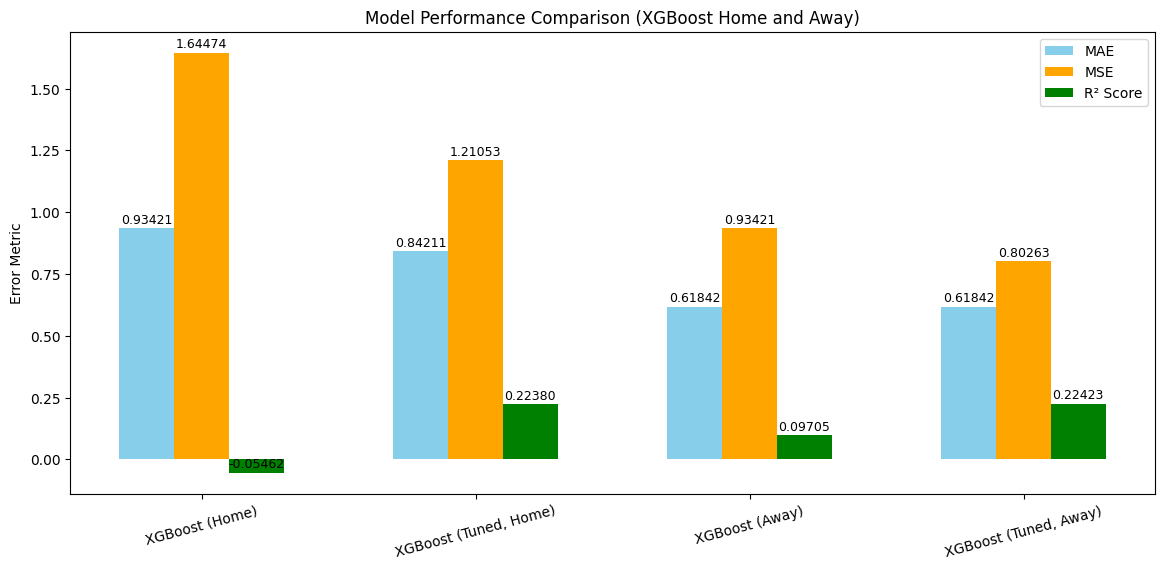

In [87]:
# Define updated models list for comparison
models = [
    'XGBoost (Home)', 'XGBoost (Tuned, Home)',
    'XGBoost (Away)', 'XGBoost (Tuned, Away)'
]
# Update x-axis positions
x = np.arange(len(models))  

# Evalutaion Metrics
mae = [
    mean_absolute_error(y_test_home, y_pred_home_xgb),          # Home XGBoost MAE
    mean_absolute_error(y_test_home, y_pred_home_optuna),      # Tuned Home XGBoost MAE
    mean_absolute_error(y_test_away, y_pred_away_xgb),         # Away XGBoost MAE
    mean_absolute_error(y_test_away, y_pred_away_optuna)       # Tuned Away XGBoost MAE
]
mse = [
    mean_squared_error(y_test_home, y_pred_home_xgb),          # Home XGBoost MSE
    mean_squared_error(y_test_home, y_pred_home_optuna),       # Tuned Home XGBoost MSE
    mean_squared_error(y_test_away, y_pred_away_xgb),          # Away XGBoost MSE
    mean_squared_error(y_test_away, y_pred_away_optuna)        # Tuned Away XGBoost MSE
]
r2 = [
    r2_score(y_test_home, y_pred_home_xgb),                    # Home XGBoost R2
    r2_score(y_test_home, y_pred_home_optuna),                 # Tuned Home XGBoost R2
    r2_score(y_test_away, y_pred_away_xgb),                    # Away XGBoost R2
    r2_score(y_test_away, y_pred_away_optuna)                  # Tuned Away XGBoost R2
]

# Plot updated metrics
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
plt.bar(x, mse, 0.2, label='MSE', color='orange')
plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

# Add annotations for each bar
for i, (mae_val, mse_val, r2_val) in enumerate(zip(mae, mse, r2)):
    plt.text(x[i] - 0.2, mae_val + 0.02, f'{mae_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i], mse_val + 0.02, f'{mse_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i] + 0.2, r2_val + 0.02, f'{r2_val:.5f}', ha='center', fontsize=9)

# Add labels, title, and legend
plt.xticks(x, models, rotation=15)  # Rotate labels for better readability
plt.ylabel('Error Metric')
plt.title('Model Performance Comparison (XGBoost Home and Away)')
plt.legend()
plt.show()


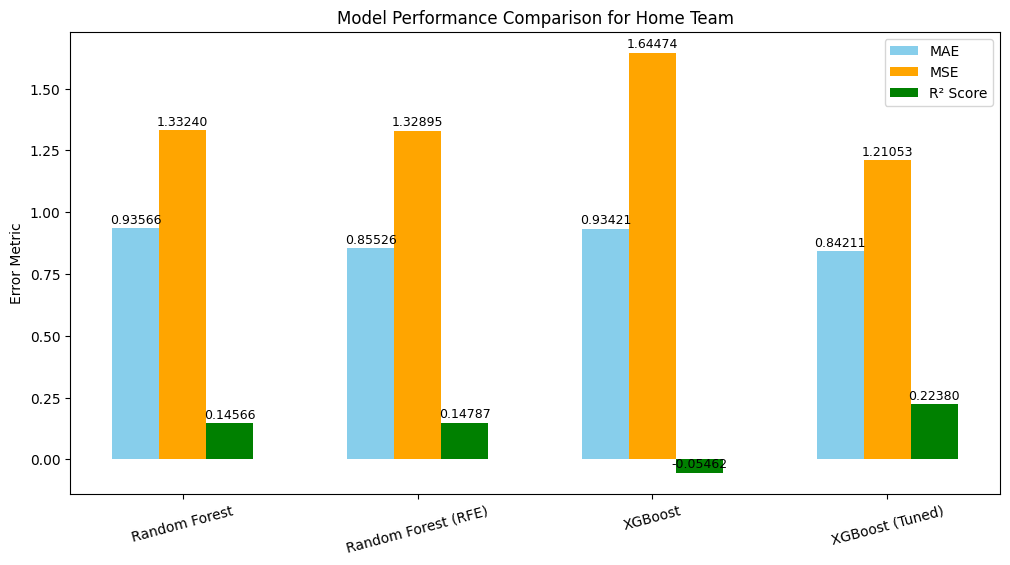

In [88]:
# Define updated models list for comparison
models = [
    'Random Forest', 'Random Forest (RFE)',
      'XGBoost', 'XGBoost (Tuned)'
]
# Update x-axis positions
x = np.arange(len(models)) 

# Evaluation Metrics
mae = [
    mean_absolute_error(y_test_home, rf_home.predict(X_test_home)),
    mean_absolute_error(y_test_home, y_pred_home_rfe),
    mean_absolute_error(y_test_home, y_pred_home_xgb),
    mean_absolute_error(y_test_home, y_pred_home_optuna)
]
mse = [
    mean_squared_error(y_test_home, rf_home.predict(X_test_home)),
    mean_squared_error(y_test_home, y_pred_home_rfe),
    mean_squared_error(y_test_home, y_pred_home_xgb),
    mean_squared_error(y_test_home, y_pred_home_optuna)
]
r2 = [
    r2_score(y_test_home, rf_home.predict(X_test_home)),
    r2_score(y_test_home, y_pred_home_rfe),
    r2_score(y_test_home, y_pred_home_xgb),
    r2_score(y_test_home, y_pred_home_optuna)
]


# Plot Comparison of Metrics
plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
plt.bar(x, mse, 0.2, label='MSE', color='orange')
plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

# Add annotations for each bar
for i, (mae_val, mse_val, r2_val) in enumerate(zip(mae, mse, r2)):
    plt.text(x[i] - 0.2, mae_val + 0.02, f'{mae_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i], mse_val + 0.02, f'{mse_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i] + 0.2, r2_val + 0.02, f'{r2_val:.5f}', ha='center', fontsize=9)

# Add labels, title, and legend
plt.xticks(x, models, rotation=15)  # Rotate labels for better readability
plt.ylabel('Error Metric')
plt.title('Model Performance Comparison for Home Team')
plt.legend()
plt.show()
